# Example: Pulse Design Tool with beta_p/li profile targets

This notebook demonstrates how to use the **FreeGSNKE Pulse Design Tool** (FPDT) in the same toy scenario as Example 11, but with the plasma current density profile evolution prescribed through physical `beta_p` and `li` targets rather than by directly prescribing Lao `alpha` and `beta` coefficients.

The virtual PCS setup, controller waveforms, machine, and initial condition are otherwise the same as Example 11. The underlying profile object remains `Lao85`; before each dynamic timestep, FreeGSNKE fits the Lao coefficients that reproduce the requested `beta_p` and `li` targets and then advances the existing evolutive solver using the corresponding coefficient change.

For this toy case there is no EFIT reconstruction. We therefore calculate `beta_p` and `li` from the initial FreeGSNKE equilibrium and keep both quantities constant throughout the dynamic solve.


### Generate a starting equilibrum

As in prior notebooks, we need a starting equilibrium. 

This equilibrium will be the initial condition from which the FPDT will evolve the plasma.

In [1]:
# package
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
# build machine
from freegsnke import build_machine
tokamak = build_machine.tokamak(
    active_coils_path=f"../machine_configs/MAST-U/MAST-U_like_active_coils.pickle",
    passive_coils_path=f"../machine_configs/MAST-U/MAST-U_like_passive_coils.pickle",
    limiter_path=f"../machine_configs/MAST-U/MAST-U_like_limiter.pickle",
    wall_path=f"../machine_configs/MAST-U/MAST-U_like_wall.pickle",
)


# initialise equilibrium
from freegsnke import equilibrium_update
eq = equilibrium_update.Equilibrium(
    tokamak=tokamak,
    Rmin=0.1, Rmax=2.0,   # Radial range
    Zmin=-2.2, Zmax=2.2,  # Vertical range
    nx=65,                # Number of grid points in the radial direction (needs to be of the form (2**n + 1) with n being an integer)
    ny=65,                # Number of grid points in the vertical direction (needs to be of the form (2**n + 1) with n being an integer)
)  

# initialise profiles
from freegsnke.jtor_update import Lao85
profiles = Lao85(
    eq=eq,                     # equilibrium object
    Ip=7.59e5,                 # plasma current
    fvac=-0.52,                # fvac = rB_{tor}
    alpha=[362685, 17696],     # Lao profiles parameters
    beta=[0.103, 0.753],       # Lao profiles parameters
    alpha_logic=True,
    beta_logic=True,
)

# set initial coil currents (passive structure currents start at zero here)
coil_currents = np.array([2766.10782056,   193.12768191,  4019.86873871,  4857.42357466,
        -726.99282376, -1696.92521166,   -77.7252396 ,   266.38207493,
         -73.01483716, -4169.86874271, -4518.28147417,   5.2  ])
for i, key in enumerate(tokamak.coil_names[0:12]):
    eq.tokamak.set_coil_current(coil_label=key, current_value=coil_currents[i])

# initialise the static solver
from freegsnke import GSstaticsolver
GSStaticSolver = GSstaticsolver.NKGSsolver(eq)    

# solve for the equilbirium
GSStaticSolver.solve(
    eq=eq, 
    profiles=profiles, 
    constrain=None, 
    target_relative_tolerance=1e-8,
    )

# plot the equilbirium
fig1, ax1 = plt.subplots(1, 1, figsize=(4, 8), dpi=70)
ax1.grid(True, which='both')
eq.plot(axis=ax1, show=False)
eq.tokamak.plot(axis=ax1, show=False)
ax1.set_xlim(0.1, 2.15)
ax1.set_ylim(-2.25, 2.25)
plt.tight_layout()

Active coils --> built from pickle file.
Passive structures --> built from pickle file.
Limiter --> built from pickle file.
Wall --> built from pickle file.


Magnetic probes --> none provided.


Resistance (R) and inductance (M) matrices --> built using actives (and passives if present).
Tokamak built.


Forward static solve SUCCESS. Tolerance 4.81e-09 (vs. requested 1.00e-08) reached in 33/100 iterations.


### Prepare inputs for the PCS class

Here, we will set up the inputs (lists and dictionaries) for each of the (internal) controller classes within the virtual PCS (e.g. plasma, shape, virtual circuits). 

We start by defining which coils have which purpose.

In [3]:
# COIL NAMES AND SHAPE TARGET NAMES

# active coils: must match the order they appear in FreeGSNKE machine description
active_coils = ['Solenoid', 'PX', 'D1', 'D2', 'D3', 'Dp', 'D5', 'D6', 'D7', 'P4', 'P5', 'P6']

# control coils: a subset of the active coils to be used for plasma and shape parameter control (i.e. we exclude vertical control coil P6 here)
ctrl_coils = ['Solenoid', 'PX', 'D1', 'D2', 'D3', 'Dp', 'D5', 'D6', 'D7', 'P4', 'P5']

# Ohmic coil (for plasma current control) 
solenoid_coils=["Solenoid"]

# vertical control coil
vertical_coils=["P6"]

# names of the plasma targets (this will be clear later, equal to the number of solenoid coils)
plasma_targets = ['plasma']

All of the following inputs are going to be specified as **waveforms**, i.e. they will be a dicitonary of **times** and **vals**. 

For each array/list of **times** (in seconds), we must specify a corresponding list of list/arrays in **vals**. 

Most waveform quantities (e.g. `*_ref`, `*_ff`, `blend`) will use **linear** interpolation inside the PCS class internally, to enable querying at a given time $t$ within the simulation.

Some other quantities (e.g. PID gains, virtual circuits, and other arrays), will use **previous-value (or step)** interpolation where the value defined at time `tmin` is used over the interval $ [t_\mathrm{min},\, t_\mathrm{next})$, after which the value defined at `tnext` is applied.

We will denote which quantity uses which type of interpolation with **linear ** or **step**. 

The following two cells provide an example of how to set these two different waveforms types and what they look like when plotted. 

In [4]:
# waveform dictionary structure (for linearly interpolated quantity)
# e.g. this could be the desired radial position of the X-point over time
waveform = {
    "times": np.array([0.0, 0.05, 0.15, 0.35, 0.45, 0.5]),
     "vals": np.array([0.57, 0.57, 0.5, 0.5, 0.57, 0.57]),
}

# plot what it looks like 
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8, 4),
    dpi=80
)

ax.plot(waveform['times'], waveform['vals'], color='k', linewidth=1, linestyle="--", marker="x", markersize=7, label="linearly interpolated waveform")

ax.set_xlabel(r"Shot time [$s$]")
ax.set_ylabel("Scalar quantity [units]")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()


/var/folders/_y/dm0w4q1j76scm_xhwnz9bsz80000gp/T/ipykernel_29855/2355852286.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [5]:
# waveform dictionary structure (for step interpolated quantity)
# e.g. this could be a proportional PID gain over time
waveform = {
    "times": np.array([0.0, 0.15, 0.3, 0.5]),
     "vals": np.array([100, 150, 75, 100]),
}

# plot what it looks like 
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8, 4),
    dpi=80
)

ax.step(waveform['times'], waveform['vals'], where='post',
        color='k', linewidth=1, linestyle="--", marker="x", markersize=7,
        label="step interpolated waveform")

ax.set_xlabel(r"Shot time [$s$]")
ax.set_ylabel("Scalar quantity [units]")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()


/var/folders/_y/dm0w4q1j76scm_xhwnz9bsz80000gp/T/ipykernel_29855/424721672.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Before we define each of the controller settings, let us define some global times, i.e. the start and end of the simulation say. 

In [6]:
# choose some min amd max simulation times
tmin = 0.0
tmax = 0.5

First, we define the desired control settings for the **plasma category**.

These waveforms govern how the plasma current, $I_p$, is controlled—either via feedback (FB), feedforward (FF), or a combination of both.

The following quantities must be specified:

- **`ip_ref`**: Plasma current feedback reference waveform \[A\] (linear).
- **`vloop_ff`**: Loop voltage feedforward reference waveform \[V·s⁻¹\] (linear).
- **`blend`**: Control blending parameter [dimensionless] (linear):
  - `1` → purely FB control  
  - `0` → purely FF control  
  - values in `(0, 1)` → mixed FB/FF control.
- **`k_prop`**: Proportional gain waveform for the FB PID controller \[s⁻¹\] (step).
- **`k_int`**: Integral gain waveform for the FB PID controller \[s⁻²\] (step).
- **`k_deriv`**: Derivative gain waveform for the FB PID controller (no units) (step). 
- **`M_solenoid`**: Mutual inductance between the plasma and solenoid (required for FF control) \[V·s·A⁻¹\] (step).

In this particular example, we will tell the PCS to hold the plasma current constant at it's starting value. 

In [7]:
# PLASMA CATEGORY DATA

# build the dictionary which will be passed to the virtual PCS (all keys below are required)
plasma_data = {}

# plasma current feedback (FB) reference waveform 
# here we hold the value for the initial equilibrium constant
plasma_data["ip_ref"] = {
    'times': np.array([tmin, tmax]),
    'vals': np.array([eq._profiles.Ip, eq._profiles.Ip])
    }

# loop voltage feedforward (FF) reference waveform (can specify the desired loop voltage on the plasma)
# (here we don't use a loop voltage as we will use the FB reference waveform above)
plasma_data["vloop_ff"] = {
    'times': np.array([tmin, tmax]),
    'vals': np.array([0, 0])
    }

# blending waveform: tells controller to use purely FB control (1), purely FF control (0), or a mixture (between 0 and 1)
# we are doing pure FB control here
plasma_data["ip_blend"] = {
    'times': np.array([tmin, tmax]),
    'vals': np.array([1, 1])
    }

# proportional gain for the FB PID controller
plasma_data["k_prop"] = {
    'times': np.array([tmin]),
    'vals': np.array([-5*4])
    }

# integral gain for the FB PID controller
plasma_data["k_int"] = {
    'times': np.array([tmin]),
    'vals': np.array([-50*2])
    }

# derivative gain for the FB PID controller
plasma_data["k_deriv"] = {
    'times': np.array([tmin]),
    'vals': np.array([0])
    }

# mutual inductance between plasma and solenoid: required for FF control
# not used here as we do not set a loop voltage
plasma_data["M_solenoid"] = {
    "times": np.array([0]), 
    "vals": np.array([1.0])
    }

plasma_data.keys()

dict_keys(['ip_ref', 'vloop_ff', 'ip_blend', 'k_prop', 'k_int', 'k_deriv', 'M_solenoid'])

Next, we define the desired control settings for the **shape category**.

First, we define a function that extracts the relevant shape parameters from the equilibrium object (here referred to as `plasma_descriptors`). In this example, we extract the following quantities:

- **`Rin`**: Inboard midplane radius.
- **`Rout`**: Outboard midplane radius.
- **`Rx`**: Radial position of the lower X-point.
- **`Zx`**: Vertical position of the lower X-point.


In [8]:
# define the descriptors function (it should return an array of values and take in an eq object)
# outputs ("measurements") from this function will be passed to the PCS later on during simulation
def plasma_descriptors(eq):

    # inboard/outboard midplane radii
    RinRout = eq.innerOuterSeparatrix()

    # find lower X-point
    # define a "box" in which to search for the lower X-point
    XPT_BOX = [[0.33, -0.88], [0.95, -1.38]]

    # mask those points
    xpt_mask = (
        (eq.xpt[:, 0] >= XPT_BOX[0][0])
        & (eq.xpt[:, 0] <= XPT_BOX[1][0])
        & (eq.xpt[:, 1] <= XPT_BOX[0][1])
        & (eq.xpt[:, 1] >= XPT_BOX[1][1])
    )
    xpts = eq.xpt[xpt_mask, 0:2].squeeze()
    if xpts.ndim > 1 and xpts.shape[0] > 1:
        opt = eq.opt[0, 0:2]
        dists = np.linalg.norm(xpts - opt, axis=1)
        idx = np.argmin(dists)  # index of closest point
        Rx, Zx = xpts[idx, :]
    else:
        Rx, Zx = xpts

    return np.array([RinRout[0], RinRout[1], Rx, Zx])

# give these descriptors some names for use in the PCS
ctrl_targets = ['Rin','Rout', 'Rx', 'Zx']

Next, we specify the waveforms used to control these shape parameters throughout the simulation.  

Not all shape parameters need to be defined in units of metres—these are simply illustrative examples.

For each shape parameter, the following waveforms must be specified:

- **`ff`**: Feedforward (FF) waveform (linear).  
  Not used in this example, but can be employed to impose a fixed offset on the parameter \[m\].

- **`ref`**: Feedback (FB) reference waveform (linear).  
  These are the desired target values of the parameter over the course of the simulation \[m\].

- **`blend`**: Control blending waveform specifying the relative contribution of FF and FB control [dimensionless](linear).
  - `0` → purely FF control  
  - `1` → purely FB control  
  - values in `(0, 1)` → mixed FF/FB control. 

- **`k_prop`**: Proportional gain waveform for the FB PID controller \[s⁻¹\] (step).

- **`k_int`**: Integral gain waveform for the FB PID controller (not used here) \[s⁻²\] (step).

- **`k_deriv`**: Derivative gain waveform for the FB PID controller (no units) (step). 

- **`damping`**: Damping waveform (not used here) [dimensionless] (step). 

In the following, we tell will tell the controllers to:

- hold both **`Rin`** and **`Rout`** constant. 
- hold **`Rx`** constant for a short period, before ramping down (to increase plasma triangularity), then ramp back up to the original value.
- allow **`Zx`** to be uncontrolled.

In [9]:
# SHAPE/DIVERTOR CATEGORY

# build the dictionary which will be passed to the virtual PCS (all keys below are required)
shape_data = {}

# waveforms for Rin
shape_data["Rin"] = {}
shape_data["Rin"]["ff"] = {"times": np.array([tmin, tmax]), "vals": np.array([0.0, 0.0])}          
shape_data["Rin"]["ref"] = {"times": np.array([tmin, tmax]), "vals": np.array([0.28, 0.28])} 
shape_data["Rin"]["blend"] = {"times": np.array([tmin, tmax]), "vals": np.array([1.0, 1.0])}
shape_data["Rin"]["k_prop"] = {"times": np.array([tmin]), "vals": np.array([120])}
shape_data["Rin"]["k_int"] = {"times": np.array([tmin]), "vals": np.array([0.0])}
shape_data["Rin"]["k_deriv"] = {"times": np.array([tmin]), "vals": np.array([0.0])}

# waveforms for Rout
shape_data["Rout"] = {}
shape_data["Rout"]["ff"] = {"times": np.array([tmin, tmax]), "vals": np.array([0.0, 0.0])}        
shape_data["Rout"]["ref"] = {"times": np.array([tmin, tmax]), "vals": np.array([1.35, 1.35])} 
shape_data["Rout"]["blend"] = {"times": np.array([tmin, tmax]), "vals": np.array([1.0, 1.0])}
shape_data["Rout"]["k_prop"] = {"times": np.array([tmin]), "vals": np.array([170])}
shape_data["Rout"]["k_int"] = {"times": np.array([tmin]), "vals": np.array([0.0])}
shape_data["Rout"]["k_deriv"] = {"times": np.array([tmin]), "vals": np.array([0.0])}

# waveforms for Rx
shape_data["Rx"] = {}
shape_data["Rx"]["ff"] = {"times": np.array([tmin, tmax]), "vals": np.array([0.0, 0.0])}       
shape_data["Rx"]["ref"] = {"times": np.array([tmin, 0.05, 0.15, 0.35, 0.45, tmax]), "vals": np.array([0.57, 0.57, 0.5, 0.5, 0.57, 0.57])}  # we vary Rx
shape_data["Rx"]["blend"] = {"times": np.array([tmin, tmax]), "vals": np.array([1.0, 1.0])}
shape_data["Rx"]["k_prop"] = {"times": np.array([tmin]), "vals": np.array([120])}
shape_data["Rx"]["k_int"] = {"times": np.array([tmin]), "vals": np.array([0.0])}
shape_data["Rx"]["k_deriv"] = {"times": np.array([tmin]), "vals": np.array([0.0])}

# waveforms for Zx
shape_data["Zx"] = {}
shape_data["Zx"]["ff"] = {"times": np.array([tmin, tmax]), "vals": np.array([0.0, 0.0])}         
shape_data["Zx"]["ref"] = {"times": np.array([tmin, tmax]), "vals": np.array([-1.24, -1.24])}   
shape_data["Zx"]["blend"] = {"times": np.array([tmin, tmax]), "vals": np.array([0.0, 0.0])}
shape_data["Zx"]["k_prop"] = {"times": np.array([tmin]), "vals": np.array([120])}
shape_data["Zx"]["k_int"] = {"times": np.array([tmin]), "vals": np.array([0.0])}
shape_data["Zx"]["k_deriv"] = {"times": np.array([tmin]), "vals": np.array([0.0])}

shape_data.keys()

dict_keys(['Rin', 'Rout', 'Rx', 'Zx'])

Next, we define the schedule of virtual circuits (VCs) in the **virtual circuits category**.

For each shape parameter in the **shape category**, a VC is required to map the discrepancy between the target value (from the shape controller) and the measured value (from the equilibrium) to requests for the poloidal field (PF) coil currents. The VCs used here were obtained using the procedure described in the example notebook on VC construction. Recall that VCs are defined with units \[m/A\].

Each VC is an array with length equal to the number of `ctrl_coils`, with entries ordered consistently with that list. When specified in the waveform dictionary, VCs are **previous-value interpolated** by the PCS class. For example, for the `Rin` controller, the VC defined at time `tmin` is used over the interval $ [t_\mathrm{min},\, t_\mathrm{max})$, after which the VC defined at `tmax` is applied. Note here that we use only one VC for each shape parameter as the shape changes are not that significant. If more complex shape changes are required, then more VCs (linearised around the expected plasma shape), will be required. 

Note that the first entry of each shape-parameter VC is zero. This ensures that the solenoid does not contribute to shape control and is reserved exclusively for plasma current, $I_p$, control.

In addition to the shape VCs, a final VC is defined for the **plasma category**. This VC maps the requested change in $I_p$ from the plasma controller to PF coil current requests (well in this case, only a request to the solenoid).

Finally, optional pre-programmed feedforward (FF) requests for the PF coil currents may be specified. These allow the coil currents to be set directly if desired. In this example, no such FF requests are used, and the coil currents are driven purely via feedback control.


In [10]:
# VIRTUAL CIRCUITS CATEGORY

# build the dictionary which will be passed to the virtual PCS (all keys below are required)
circuits_data = {}

circuits_data["Rin"] = {
    "times": np.array([tmin]), 
    "vals": [
        np.array([0, 3.1394e+04,  8.5990e+03, -8.8300e+02, -1.2460e+03, -6.6690e+03, 1.2660e+03,  2.9770e+03,  3.5350e+03,  8.3110e+03, -7.8520e+03]),
        ]
    }

circuits_data["Rout"] = {
    "times": np.array([tmin]), 
    "vals": [
        np.array([0, -9.9700e+02,  1.1790e+03,  3.9700e+02, -2.0000e+02, -1.8970e+03, -5.5500e+02, -2.2640e+03, -1.5860e+03, -1.9750e+03,  5.5800e+03]),
        ]
    }

circuits_data["Rx"] = {
    "times": np.array([tmin]), 
    "vals": [
        np.array([0, -3.0021e+04,  3.3980e+03,  8.6900e+03,  5.8310e+03,  1.5858e+04, 2.4000e+01, -1.2100e+02, -2.2160e+03, -9.5290e+03,  1.3570e+03]),
        ]
    }

circuits_data["Zx"] = {
    "times": np.array([tmin]), 
    "vals": [
        np.array([0, 3.7670e+03,  2.0328e+04,  1.0562e+04,  4.2560e+03,  2.2600e+03, -2.0450e+03, -5.5680e+03, -5.3160e+03, -9.8440e+03,  3.3750e+03]),
        ]
    }

circuits_data["plasma"] = {
    "times": np.array([tmin]), 
    "vals": [
        np.array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
        ]
    }

# store the coil order for future reference
circuits_data["coil_order"] = ctrl_coils

# define any feedforward coil current drives on each control coil (no drives used here)
zeros_dict = {"times": np.array([tmin, tmax]), "vals": np.array([0.0, 0.0])}
for coil in ctrl_coils: # linearly interpolated
    circuits_data[coil+"_ref"] = zeros_dict

circuits_data.keys()

dict_keys(['Rin', 'Rout', 'Rx', 'Zx', 'plasma', 'coil_order', 'Solenoid_ref', 'PX_ref', 'D1_ref', 'D2_ref', 'D3_ref', 'Dp_ref', 'D5_ref', 'D6_ref', 'D7_ref', 'P4_ref', 'P5_ref'])

Next, we define the inputs for the **systems category**.

This controller specifies operational limits for the coils listed in `ctrl_coils`, including:

- **`min_coil_curr_lims`**: Minimum allowable coil currents \[A\] (step).
- **`max_coil_curr_lims`**: Maximum allowable coil currents \[A\] (step).
- **`max_coil_curr_ramp_lims`**: Maximum allowable coil current ramp rates \[A·s⁻¹\] (step).

There is also the option to define feedforward (FF) perturbations (linear) to the control coil currents—similar to the FF drives available in the **virtual circuits category**. These are not used here.


In [11]:
# SYSTEMS CATEGORY

# build the dictionary which will be passed to the virtual PCS (all keys below are required)
systems_data = {}

# define the min coil current limits and ramp rate limits
systems_data["min_coil_curr_lims"] = {
    'times': [0.0],
    'vals': [np.array([-10000, -7000, -9000, -9000, -9000, -9000, -9000, -9000, -9000, -10000, -10000])],
    }

# define the max coil current limits
systems_data["max_coil_curr_lims"] = {
    'times': [0.0],
    'vals': [np.array([10000, 7000, 9000, 9000, 9000, 9000, 9000, 9000, 9000, 0, 0])],
    }

# define the max ramp rate limits for the coils
systems_data["max_coil_curr_ramp_lims"] = {
    'times': [0.0],
    'vals': [1e12*np.ones(len(ctrl_coils))],
    }

# define the control coil current perturbations
for name in ctrl_coils: # linearly interpolated
    systems_data[name+"_pert"] = zeros_dict

systems_data.keys()

dict_keys(['min_coil_curr_lims', 'max_coil_curr_lims', 'max_coil_curr_ramp_lims', 'Solenoid_pert', 'PX_pert', 'D1_pert', 'D2_pert', 'D3_pert', 'Dp_pert', 'D5_pert', 'D6_pert', 'D7_pert', 'P4_pert', 'P5_pert'])

Next, we define the inputs for the **PF category**.

This category specifies the electrical properties, gains, and operational limits of the poloidal field (PF) coils. These inputs are used by the virtual PCS to convert coil current requests into physically consistent voltage commands.

The following quantities must be provided:

- **`R_matrix`**: Coil resistance array for the PF coils \[Ω\] (step).  
  Defined as a time-dependent waveform and restricted to the coils listed in `ctrl_coils`.

- **`M_FF_matrix`**: Coil mutual inductance matrix used in feedforward (FF) terms \[Vs/A\] (step).  
  This accounts for inductive coupling between PF coils when computing FF voltage requests.

- **`M_FB_matrix`**: Coil mutual inductance matrix used in feedback (FB) terms \[Vs/A\] (step).
  This accounts for inductive coupling between PF coils when computing FF voltage requests. Often it is identical to `M_FF_matrix`, but is provided separately for flexibility.

- **`coil_gains`**: Feedback gain applied to each PF coil \[s\] (step).  
  These gains scale the feedback voltage contributions on a per-coil basis.

- **`coil_voltage_lims`**: Maximum allowable voltages for each PF coil \[V\] (step).  
  These limits are enforced by the PCS when generating coil voltage commands.

- **`coil_voltage_slew_lims`**: Maximum allowable voltage ramp rates for each PF coil \[V·s⁻¹\] (step).  
  In this example, very large values are used, effectively disabling slew-rate limiting.

All quantities are defined as time-dependent waveforms, even when constant, to allow future extension to time-varying PF system parameters.


In [12]:
# PF CATEGORY

# build the dictionary which will be passed to the virtual PCS (all keys below are required)
pf_data = {}

# coil resistances
pf_data["R_matrix"] = {
    'times': [0.0],
    'vals': [tokamak.coil_resist[0:11]],
    }

# coil mutual inductances (on feedforward terms)
pf_data["M_FF_matrix"] = {
    'times': [0.0],
    'vals': [tokamak.coil_self_ind[0:11,0:11]],
    }

# coil mutual inductances (on feedback terms)
pf_data["M_FB_matrix"] = {
    'times': [0.0],
    'vals': [tokamak.coil_self_ind[0:11,0:11]],
    }


# gains on the coils (for feedback term)
pf_data["coil_gains"] = {
    'times': [0.0],
    'vals': [0.015*np.ones(len(ctrl_coils))],
    }

# limits on voltages in the coils
pf_data["coil_voltage_lims"] = {
    "times": np.array([0.0]),
    'vals': [[2000,  750,  750,  750,  750,  750,  750,  750,  750,  750,  750]],
     } 

# limits on voltage ramp rates in the coils (we set no limits here)
pf_data["coil_voltage_slew_lims"] = {
    'times': [0.0],
    'vals': [1e12*np.ones(len(ctrl_coils))],
    }

pf_data.keys()

dict_keys(['R_matrix', 'M_FF_matrix', 'M_FB_matrix', 'coil_gains', 'coil_voltage_lims', 'coil_voltage_slew_lims'])

Next, we define the inputs for the **vertical category**.

This category configures the feedback controller responsible for stabilising and controlling the vertical position of the plasma column using the vertical control coil (here the `P6` coil). 

The following quantities must be specified:

- **`z_ref`**: Plasma vertical position reference waveform \[m\] (linear).  
  This defines the desired vertical position of the plasma as a function of time.

- **`k_prop`**: Proportional gain waveform for the vertical position feedback controller \[s⁻¹\] (step).  
  This gain determines the strength of the restoring force in response to vertical displacement.

- **`k_deriv`**: Derivative gain waveform for the vertical position feedback controller \[s⁻²\] (step).
  This term provides damping by responding to the rate of change of the vertical position.

All inputs are defined as time-dependent waveforms, allowing for time-varying vertical control behaviour if required.

In this example, we steadily increase the vertical position to before holding it constant thereafter. 

In [13]:
# VERTICAL CATEGORY DATA

# build the dictionary which will be passed to the virtual PCS (all keys below are required)
vertical_data = {}

# plasma vertical position reference
vertical_data["z_ref"] = {"times": np.array([tmin, tmin+0.25, tmax]), "vals": np.array([0.0, 0.01, 0.01])}

# proportional gain
vertical_data["k_prop"] = {"times": np.array([tmin]), "vals": np.array([0.025])}

# derivative gain
vertical_data["k_deriv"] = {"times": np.array([tmin]), "vals": np.array([5e-7])}

vertical_data.keys()

dict_keys(['z_ref', 'k_prop', 'k_deriv'])

Finally, we define the inputs for the **coil activations category**.

This category specifies when each active poloidal field (PF) coil is enabled or disabled during the simulation. Coil activations are represented as time-dependent waveforms and are applied on a per-coil basis.

For each coil listed in `active_coils`, the following entry is defined:

- **`<coil_name>_activation`**: Coil activation waveform (step).  
  A value of:
  - `1.0` indicates that the coil is active and available to the PCS.
  - `0.0` indicates that the coil is inactive and excluded from PCS.

In this example, all coils are activated for the entire simulation interval $[t_\mathrm{min},\, t_\mathrm{max}]$, using constant activation waveforms. This structure allows coils to be selectively enabled or disabled at different times in more advanced scenarios.


In [14]:
# COIL ACTIVATIONS CATEGORY

# build the dictionary which will be passed to the virtual PCS (all keys below are required)
coil_activation_data = {}

# coil activation times
default_coil_dict = {"times": np.array([tmin]), "vals": np.array([1.0])}
for name in active_coils:
    coil_activation_data[name+"_activation"] = default_coil_dict

coil_activation_data.keys()

dict_keys(['Solenoid_activation', 'PX_activation', 'D1_activation', 'D2_activation', 'D3_activation', 'Dp_activation', 'D5_activation', 'D6_activation', 'D7_activation', 'P4_activation', 'P5_activation', 'P6_activation'])

### Initialise the virtual PCS class

Now that the inputs have been prepared we can initialise the class and use in-built functions to view or plot the waveform data in each control category. This will build internal classes for each of the above listed controllers. 

In [15]:
# FIRE UP THE PLASMA CONTROL SYSTEM
from freegsnke.control_loop.pcs import PlasmaControlSystem

PCS = PlasmaControlSystem(
    plasma_data=plasma_data,
    shape_data=shape_data,
    shape_control_mode="PID",
    circuits_data=circuits_data,
    systems_data=systems_data,
    pf_data=pf_data,
    vertical_data=vertical_data,
    coil_activation_data=coil_activation_data,
    active_coils=active_coils,
    ctrl_coils=ctrl_coils,
    solenoid_coils=solenoid_coils,
    vertical_coils=vertical_coils,
    ctrl_targets=ctrl_targets,
    plasma_target=plasma_targets,
)

In [16]:
# each controller should contain a copy of the waveform dictionaries internally
PCS.PlasmaController.data

{'ip_ref': {'times': array([0. , 0.5]), 'vals': array([759000., 759000.])},
 'vloop_ff': {'times': array([0. , 0.5]), 'vals': array([0, 0])},
 'ip_blend': {'times': array([0. , 0.5]), 'vals': array([1, 1])},
 'k_prop': {'times': array([0.]), 'vals': array([-20])},
 'k_int': {'times': array([0.]), 'vals': array([-100])},
 'k_deriv': {'times': array([0.]), 'vals': array([0])},
 'M_solenoid': {'times': array([0]), 'vals': array([1.])}}

In [17]:
# it will also contain a dictionary of functions that has linearly (or previous value) interpolated the various waveforms
PCS.PlasmaController.interpolants

{'ip_ref': <scipy.interpolate._fitpack2.InterpolatedUnivariateSpline at 0x3138c19f0>,
 'vloop_ff': <scipy.interpolate._fitpack2.InterpolatedUnivariateSpline at 0x3138c2f20>,
 'ip_blend': <scipy.interpolate._fitpack2.InterpolatedUnivariateSpline at 0x313674c70>,
 'k_prop': <scipy.interpolate._interpolate.interp1d at 0x11fe687c0>,
 'k_int': <scipy.interpolate._interpolate.interp1d at 0x11fe6aca0>,
 'k_deriv': <scipy.interpolate._interpolate.interp1d at 0x11fe6ab60>,
 'M_solenoid': <scipy.interpolate._interpolate.interp1d at 0x11fe6ab10>}

In [18]:
# # it should also be possible to plot the data (uncomment following cell)
# # green shading indiciates times that FB control is ON, yellow that FF is ON, a mix that both are ON, and white that there is no control
# PCS.PlasmaController.plot_data(tmin=tmin, tmax=tmax)

In [19]:
# the "run_control" method will be used internally later on but can also be called explicitly if required
PCS.PlasmaController.run_control

<bound method PlasmaController.run_control of <freegsnke.control_loop.plasma_category.PlasmaController object at 0x3138c2890>>

Finally, suppose you wish to modify the shot setup data after initialising the PCS class. 

To do this, simply edit the waveforms required directly in the `.data` attribute of the controller of interest and then call `.update_interpolants()`. This has to be done to ensure that the controller refreshes any stale interpolants from a prior initialisation.

Uncomment the code below to see how it works for an example in the `ShapeController`.

In [20]:
# # update the data entry with your new waveform
# new_waveform = {"times": np.array([tmin, 0.05, 0.15, 0.35, 0.45, tmax]), "vals": np.array([0.28, 0.28, 0.30, 0.30, 0.28, 0.28])}  # we vary Rin
# PCS.ShapeController.data["Rin"]["ref"] = new_waveform

# # call the update function to refresh inteprolants (essential)
# PCS.ShapeController.update_interpolants()

# # plot to see new waveform
# PCS.ShapeController.plot_data(targ="Rin", tmin=tmin, tmax=tmax)

### Initialise the nonlinear solver object
Now choose the desired settings for the nonlinear solver object - recall the prior example notebook on this. 

The simulation timestep will be modified later on but be sure to choose a value that is 5-10x smaller than the vertical instability timescale returned in the output of this cell - this keeps the simulation numerically stable. 

In [21]:
from freegsnke import nonlinear_solve

stepping = nonlinear_solve.nl_solver(
    eq=eq, 
    profiles=profiles, 
    GSStaticSolver=GSStaticSolver,
    full_timestep=5e-4, 
    plasma_resistivity=1e-7,
    fix_n_vessel_modes=30,               
    plasma_descriptor_function=plasma_descriptors,
    )

-----
Checking that the provided 'eq' and 'profiles' are a GS solution...
Forward static solve SUCCESS. Tolerance 4.81e-09 (vs. requested 1.00e-08) reached in 0/100 iterations.
-----
Instantiating nonlinear solver objects...


done.
-----
Identifying mode selection criteria...


      'fix_n_vessel_modes' option selected --> passive structure modes that couple most to the strongest passive structure mode are being selected.
-----
Initial mode selection:
   Active coils
      total selected = 12 (out of 12)
   Passive structures
      30 selected using 'fix_n_vessel_modes'
   Total number of modes = 42 (12 active coils + 30 passive structures)
      (Note: some additional modes may be removed after Jacobian calculation if 'mode_removal=True')
-----
Building the 1513 x 43 Jacobian (dIy/dI) of plasma current density (inside the LCFS) with respect to all metal currents and the total plasma current.


Building the 1513 x 4 Jacobian (dIy/dtheta) of plasma current density (inside the LCFS) with respect to all plasma current density profile parameters within Jtor.


Built the 4 x 43 Jacobian (ds/dI) of plasma descriptors with respect to all metal currents and the total plasma current.
Built the 4 x 4 Jacobian (ds/dtheta) of plasma descriptors with respect to all plasma current density profile parameters within Jtor.
-----
Stability paramters:


   Deformable plasma metrics:
      Growth rate = [27.20271834] [1/s]
      Instability timescale = [0.03676103] [s]
      Inductive stability margin = [0.75454395+0.j]
   Rigid plasma metrics:
      Leuer parameter (ratio of stabilsing to de-stabilising force gradients):
          between all metals and all metals = 2.0951036090628343
          between all metals and active metals = 2.0951036090628343
          between passive metals and active metals = 2.0950856699675153
-----
Evolutive solver timestep:
      Solver timestep 'dt_step' has been set to 0.0005 as requested.
      Ensure it is smaller than the growth rate else you may find numerical instability in any subsequent evoltuive simulations!
-----


### Define FPDT simulation parameters

Next set the key simulation parameters for the FPDT.

In [22]:
# FPDT SETUP

# number of simulation time steps
n = 500

# simulation time step size (must be smaller than the vertical instability timescale)
dt = 1e-3

# PCS time step (this must be whole fraction of the simulation time step)
# it governs the frequency at which the PCS is called
dt_PCS = 1e-4

# starting time (leave as it is)
tmin = 0.0

# automatically calculates time array and sets time step in solver object
stepping.dt_step = dt
t_end = tmin + n*dt
times = np.arange(tmin, t_end, dt)

# (re-)initialise the dynamic solver with the initial eq and profiles
stepping.initialize_from_ICs(eq, profiles)

Before moving forward, we set up the profile evolution targets. Example 11 keeps the Lao `alpha` and `beta` coefficients constant directly. In this variant, we instead calculate the initial-condition `beta_p` and `li` from the toy equilibrium and keep those physical quantities constant.

The evolutive solver still uses `Lao85` profiles internally. When the time loop passes `profiles_parameters={"betap": ..., "li": ...}`, the solver converts these physical targets into the Lao `alpha` and `beta` coefficients needed by the linearised profile-response model.


In [23]:
# PROFILE EVOLUTION TARGETS

# There is no EFIT reconstruction in this toy FPDT example. Use the solved
# initial condition to define constant physical profile targets.
initial_betap = eq.poloidalBeta1()
initial_li = eq.internalInductance2()

profile_betap_ref = {
    "times": np.array([tmin, t_end]),
    "vals": np.array([initial_betap, initial_betap]),
}
profile_li_ref = {
    "times": np.array([tmin, t_end]),
    "vals": np.array([initial_li, initial_li]),
}

profile_constraint_options = {
    "li_method": "internalInductance2",
    "target_relative_tolerance": 1e-7,
    "max_solving_iterations": 40,
    "optimizer_kwargs": {"max_nfev": 2},
    "regularization_weight": 1e-6,
    "use_metric_jacobian": True,
    "reuse_metric_jacobian": True,
    "linearized_metric_update": True,
    "linearized_metric_regularization": 1e-8,
    "linearized_metric_step_fraction": 0.25,
}

print(f"Constant beta_p target = {initial_betap:.4g}")
print(f"Constant li target     = {initial_li:.4g}")


Constant beta_p target = 0.2983
Constant li target     = 0.6694


### FPDT Simulation

In the following cell, we initialise lists/arrays to store any equilbirium related data we wish to view after the simulation. See the FreeGSNKE example notebook (example03 - extracting_equilibrium_quantites) for a list of these and how to extract them. 

Note that some quantities can be computationally costly to extract and have not been optimised for speed yet!

In [24]:
# equilibrium-related data storage
dynamic_psi = np.zeros((stepping.eq1.psi().shape[0], stepping.eq1.psi().shape[1], len(times)))    # total poloidal flux
dynamic_limiter_flag = np.zeros(len(times))                                                       # flag if plasma is limited
dynamic_psi_boundary = np.zeros(len(times))                                                       # poloidal flux on plasma boundary
dynamic_xpts = []                                                                                 # list of X-point locations and associated poloidal flux
dynamic_opts = []                                                                                 # list of O-point locations and associated poloidal flux
dynamic_currents = np.zeros((len(stepping.currents_vec[:-1]),len(times)))                         # PF coil and vessel eigenmode currents 
dynamic_ip = np.zeros(len(times))                                                                 # total plasma current
dynamic_shape_targets = np.zeros((len(ctrl_targets),len(times)))                                  # shape parameters
dynamic_timings = np.zeros(len(times))                                                            # solver runtime at each time step
dynamic_triangularity = np.zeros(len(times))                                                      # plasma triangularity
dynamic_betap = np.zeros(len(times))                                                             # achieved poloidal beta
dynamic_li = np.zeros(len(times))                                                                # achieved internal inductance
profile_betap_target = np.zeros(len(times))                                                      # requested poloidal beta
profile_li_target = np.zeros(len(times))                                                         # requested internal inductance

# PCS-related data storage
V_approved = np.zeros((len(ctrl_coils)+1,len(times)))                                             # final PF coil voltages from the PCS class (passed into solver)
ip_hist = np.zeros(len(times))                                                                    # integral term feeding into Plasma Category PID FB controller (at prior time step)
ip_err = np.zeros(len(times))                                                                     # (error) for derivative term feeding into Plasma Category PID FB controller (at prior time step)
T_err = np.zeros((len(ctrl_targets),len(times)))                                                  # proportional term feeding into Shape Category PID FB controller (at prior time step)
T_hist = np.zeros((len(ctrl_targets),len(times)))                                                 # integral term feeding into Shape Category PID FB controller (at prior time step)
I_approved = np.zeros((len(ctrl_coils),len(times)))                                               # approved PF coil currents from prior time step feeding into System Category
coil_resists = np.zeros((len(active_coils),len(times)))                                           # PF coil resistances (to tell solver if a coil is switched on or off)
z_current = []                                                                                    # vertical position of the plasma (average jtor position)
dynamic_jtor_norm = []                                                                            # norm change in jtor between time steps (used to trigger relinearisation)
threshold = None                                                                                  # relative jtor threshold (since last linearisation) above which relinearisation is triggered (here not used)

# extract any initial values from the initial equilibrium
dynamic_psi[:,:,0] = stepping.eq1.psi()
dynamic_limiter_flag[0] = stepping.eq1._profiles.flag_limiter
dynamic_psi_boundary[0] = stepping.eq1._profiles.psi_bndry
dynamic_xpts.append(stepping.eq1.xpt)
dynamic_opts.append(stepping.eq1.opt)
dynamic_currents[:,0] = stepping.currents_vec[:-1].copy()
dynamic_ip[0] = stepping.profiles1.Ip
dynamic_shape_targets[:,0] = plasma_descriptors(eq=stepping.eq1)
dynamic_triangularity[0] = eq.triangularity()
dynamic_betap[0] = stepping.eq1.poloidalBeta1()
dynamic_li[0] = stepping.eq1.internalInductance2()
profile_betap_target[0] = np.interp(times[0], profile_betap_ref["times"], profile_betap_ref["vals"])
profile_li_target[0] = np.interp(times[0], profile_li_ref["times"], profile_li_ref["vals"])
z_current.append(stepping.eq1.Zcurrent())

Before running the following cell (which takes a few minutes), be sure to familiarise yourself with all of the steps.

During each time step:

1. The primary method in the `PCS` class, `calculate_ctrl_voltages`, is called. Using “measurements” from the current equilibrium (plasma current, coil currents, and shape parameters), it computes the voltages to be applied to the evolutive solver, as well as the coil resistances (to determine whether any coils are switched off). These voltages enact the plasma control.

2. The plasma current density profile targets are placed into a dictionary for use by the evolutive solver. In this example, the targets are constant `betap` and `li` values calculated from the toy initial condition; the solver converts them to the Lao `alpha` and `beta` coefficients required by the linearised profile-response model.

3. The evolutive solver is then called using these parameters (along with additional ones). At this stage, several choices can be made:
   - Specify a time-dependent plasma resistivity (usually required for resimulation of prior discharges).
   - Select, via `linear_only`, either a linear or fully nonlinear solution of the circuit, plasma, and Grad–Shafranov equations.
   - Set a relinearisation threshold when using linear mode (see example notebook 05c).
   - Choose not to solve the Grad–Shafranov equation fully (whenusing linear mode), but instead solve only for the shape parameters specified in `plasma_descriptors` (see example notebooks 05b and 05c).

4. The required data are stored following successful completion of the time step.


In [25]:
# RUN FPDT SIMULATION
for i, t in enumerate(times[0:-1]):
    print("-----")
    print(f"t = {np.round(t,5)}s (step {i+1}/{n-1})")
    
    # start timer
    start_time = time.time()

    # initialise any historical quantities for PCS PID controllers
    if i == 0:
        ip_hist_prev = 0.0
        ip_err_prev = 0.0
        T_err_prev = np.zeros(len(ctrl_targets))
        T_hist_prev = np.zeros(len(ctrl_targets))
        I_approved_prev = eq.tokamak.getCurrentsVec()[0:11]  # must use starting currents here
        V_approved_prev = np.zeros(len(ctrl_coils))
        zipv_meas = 0.0
    else:
        ip_hist_prev=ip_hist[i-1].copy()                              # integral term from FB PID Plasma controller at prior step
        ip_err_prev=ip_err[i-1].copy()                                # error term from FB PID Plasma controller at prior step
        T_err_prev=T_err[:,i-1].copy()                                # proportional term from FB PID Shape controller at prior step
        T_hist_prev=T_hist[:,i-1].copy()                              # integral term from FB PID Shape controller at prior step
        I_approved_prev=I_approved[:,i-1].copy()                      # approved PF coil currents from prior step (ctrl_coils only)
        V_approved_prev=V_approved[0:-1,i-1].copy()                   # approved PF coil voltages from prior step (ctrl_coils only)
        zipv_meas = ((z_current[-1]-z_current[-2])/dt)*dynamic_ip[i]  # rate of change of vertical plasma position 
    
    # call the PCS class to attain PF coil voltages (on ctrl_coils and vertical coil)
    V_approved[:,i], ip_hist[i], ip_err[i], T_err[:,i], T_hist[:,i], I_approved[:,i], coil_resists[:,i] = PCS.calculate_ctrl_voltages(
        t=t,                                        # current simulation time
        dt=dt_PCS,                                  # PCS time step
        dt_simulator=dt,                            # simulator (solver) time step
        ip_meas=dynamic_ip[i],                      # measured plasma current
        ip_hist_prev=ip_hist_prev,                  # plasma controller integral term history
        ip_err_prev=ip_err_prev,                    # plasma controller error term history (for derivative term)
        T_meas=dynamic_shape_targets[:,i].copy(),   # measured shape parameters
        T_err_prev=T_err_prev,                      # shape controller proportional term history
        T_hist_prev=T_hist_prev,                    # shape controller integral term history
        I_approved_prev=I_approved_prev,            # approved PF currents from prior timestep
        I_meas=dynamic_currents[0:11,i].copy(),     # measured PF coil currents
        V_approved_prev=V_approved_prev,            # approved PF voltages from prior timestep
        zip_meas=z_current[i]*dynamic_ip[i],        # measured vertical position x measured plasma current
        zipv_meas=zipv_meas,                        # derivative of above
        active_coil_resists=tokamak.coil_resist[0:12].copy(),    # PF coil resistances (these are constant)
        verbose=False,                              # print some output?
    )

    # prescribe the end-of-step physical profile targets. The solver converts
    # these beta_p/li values to Lao alpha/beta coefficients internally.
    profile_params = {
        "betap": float(np.interp(t + dt, profile_betap_ref["times"], profile_betap_ref["vals"])),
        "li": float(np.interp(t + dt, profile_li_ref["times"], profile_li_ref["vals"])),
    }

    # run freegsnke over the time step with the calculated voltages
    stepping.nlstepper(
        plasma_resistivity=1e-7,                          # assign plasma resistivity (chosen to be constant here)
        active_voltage_vec=V_approved[:,i],               # assign approved PF coil voltages from the PCS
        profiles_parameters=profile_params,               # assign physical profile targets
        profile_constraint_options=profile_constraint_options,  # options for fitting beta_p/li to Lao alpha/beta
        custom_active_coil_resistances=coil_resists[:,i], # assign active coil resistances from PCS (tells solver if any coils are switched off)
        linear_only=True,                                 # linear or nonlinear solve?
        target_relative_tol_currents=1e-2,                # relative tolerance in the currents required for convergence
        target_relative_tol_GS=1e-2,                      # relative tolerance in the plasma flux required for convergence
        working_relative_tol_GS=(1e-2)/2,                 # tolerance used when solving GS equation, expressed in terms of the change in the plasma flux due to one timestep of evolution (must be smaller tolerance above)
        verbose=False,                                    # print some output?
        relinearise_threshold=threshold,                  # if the relative jtor norm change from last linearisation is above threshold, relinearise around current equilibrium
        no_GS=False,                                      # do not solve GS at each time?
        )

    # stop timer
    end_time = time.time()

    # extract and store relevant data
    dynamic_psi[:,:,i+1] = stepping.eq1.psi()
    dynamic_limiter_flag[i+1] = stepping.eq1._profiles.flag_limiter
    dynamic_psi_boundary[i+1] = stepping.eq1._profiles.psi_bndry
    dynamic_xpts.append(stepping.eq1.xpt)
    dynamic_opts.append(stepping.eq1.opt)
    dynamic_currents[:,i+1] = stepping.currents_vec[:-1].copy()
    dynamic_ip[i+1] = stepping.currents_vec[-1] * stepping.plasma_norm_factor
    dynamic_shape_targets[:,i+1] = plasma_descriptors(stepping.eq1)
    dynamic_timings[i] = end_time - start_time
    dynamic_triangularity[i+1] = stepping.eq1.triangularity()
    dynamic_betap[i+1] = stepping.eq1.poloidalBeta1()
    dynamic_li[i+1] = stepping.eq1.internalInductance2()
    profile_betap_target[i+1] = profile_params["betap"]
    profile_li_target[i+1] = profile_params["li"]
    z_current.append(stepping.eq1.Zcurrent())
    dynamic_jtor_norm.append(stepping.relinearise_criteria)

    # print some stuff to track solve
    print(f"      Ip = {np.round(dynamic_ip[i+1]/1000,1)} [kA]")
    print(f"      Shape parameters {ctrl_targets} = {np.round(dynamic_shape_targets[:,i+1],3)}")
    print(f"      Z position = {np.round(z_current[i+1],5)} [m]")
    print(f"      beta_p/li = {dynamic_betap[i+1]:.4g} / {dynamic_li[i+1]:.4g}")


-----
t = 0.0s (step 1/499)


      Ip = 759.0 [kA]
      Shape parameters ['Rin', 'Rout', 'Rx', 'Zx'] = [ 0.277  1.347  0.567 -1.245]
      Z position = 0.00034 [m]
      beta_p/li = 0.2982 / 0.673
-----
t = 0.001s (step 2/499)


      Ip = 758.8 [kA]
      Shape parameters ['Rin', 'Rout', 'Rx', 'Zx'] = [ 0.278  1.348  0.568 -1.246]
      Z position = 8e-05 [m]
      beta_p/li = 0.3012 / 0.6697
-----
t = 0.002s (step 3/499)


      Ip = 758.7 [kA]
      Shape parameters ['Rin', 'Rout', 'Rx', 'Zx'] = [ 0.278  1.347  0.568 -1.246]
      Z position = 0.00018 [m]
      beta_p/li = 0.3009 / 0.669
-----
t = 0.003s (step 4/499)


      Ip = 758.5 [kA]
      Shape parameters ['Rin', 'Rout', 'Rx', 'Zx'] = [ 0.278  1.347  0.568 -1.246]
      Z position = 0.00027 [m]
      beta_p/li = 0.2998 / 0.6684
-----
t = 0.004s (step 5/499)


...

      Ip = 759.0 [kA]
      Shape parameters ['Rin', 'Rout', 'Rx', 'Zx'] = [ 0.282  1.353  0.573 -1.251]
      Z position = 0.01006 [m]
      beta_p/li = 0.2993 / 0.6683
-----
t = 0.495s (step 496/499)


      Ip = 759.0 [kA]
      Shape parameters ['Rin', 'Rout', 'Rx', 'Zx'] = [ 0.281  1.351  0.573 -1.251]
      Z position = 0.0099 [m]
      beta_p/li = 0.2976 / 0.6692
-----
t = 0.496s (step 497/499)


      Ip = 759.0 [kA]
      Shape parameters ['Rin', 'Rout', 'Rx', 'Zx'] = [ 0.281  1.352  0.573 -1.251]
      Z position = 0.01005 [m]
      beta_p/li = 0.2978 / 0.6706
-----
t = 0.497s (step 498/499)


      Ip = 759.1 [kA]
      Shape parameters ['Rin', 'Rout', 'Rx', 'Zx'] = [ 0.282  1.353  0.573 -1.251]
      Z position = 0.01006 [m]
      beta_p/li = 0.2992 / 0.6688
-----
t = 0.498s (step 499/499)


      Ip = 759.1 [kA]
      Shape parameters ['Rin', 'Rout', 'Rx', 'Zx'] = [ 0.281  1.352  0.572 -1.251]
      Z position = 0.00992 [m]
      beta_p/li = 0.2981 / 0.6685


### Plot some results

Let's now plot some of the output. We can compare the evolution of the controlled parameters (plasma current, shape parameters, and vertical position) against their FB reference waveforms. In these plots:
- the black dashed indicated the FB reference waveform. 
- the solid blue the simulated quantity.
- green background shading indicates when FB control is ON. 
- yellow background shading indicates when FF control is ON (not used). 
- white background shading indicates no control is used.

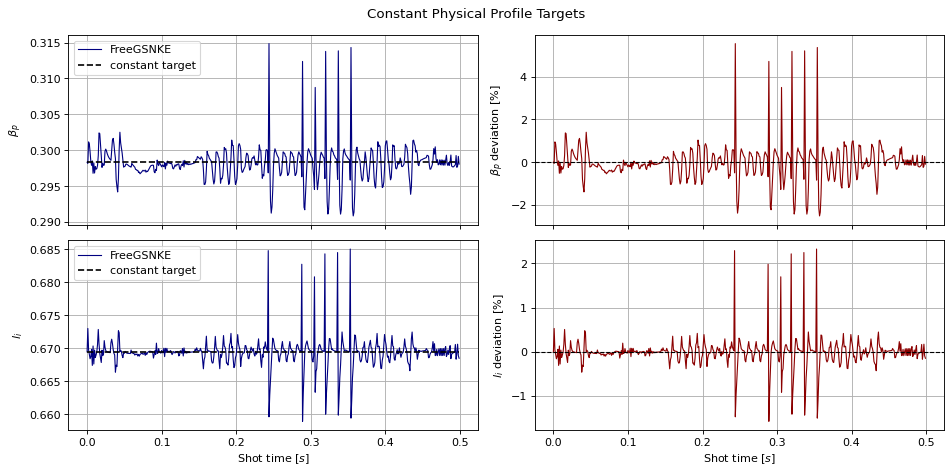

Maximum |beta_p target deviation| = 5.54%
Maximum |li target deviation|     = 2.33%


In [26]:
# PROFILE TARGET EVOLUTION
from io import BytesIO
from IPython.display import Image, display

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 6),
    dpi=80,
    sharex="col",
)

axes[0, 0].plot(times, dynamic_betap, color="navy", linewidth=1, label="FreeGSNKE")
axes[0, 0].plot(times, profile_betap_target, color="k", linestyle="--", linewidth=1.5, label="constant target")
axes[0, 0].set_ylabel(r"$\beta_p$")
axes[0, 0].grid()
axes[0, 0].legend()

axes[1, 0].plot(times, dynamic_li, color="navy", linewidth=1, label="FreeGSNKE")
axes[1, 0].plot(times, profile_li_target, color="k", linestyle="--", linewidth=1.5, label="constant target")
axes[1, 0].set_xlabel(r"Shot time [$s$]")
axes[1, 0].set_ylabel(r"$l_i$")
axes[1, 0].grid()
axes[1, 0].legend()

betap_percent_error = 100 * (dynamic_betap - profile_betap_target) / profile_betap_target
li_percent_error = 100 * (dynamic_li - profile_li_target) / profile_li_target

axes[0, 1].plot(times, betap_percent_error, color="darkred", linewidth=1)
axes[0, 1].axhline(0.0, color="k", linestyle="--", linewidth=1)
axes[0, 1].set_ylabel(r"$\beta_p$ deviation [%]")
axes[0, 1].grid()

axes[1, 1].plot(times, li_percent_error, color="darkred", linewidth=1)
axes[1, 1].axhline(0.0, color="k", linestyle="--", linewidth=1)
axes[1, 1].set_xlabel(r"Shot time [$s$]")
axes[1, 1].set_ylabel(r"$l_i$ deviation [%]")
axes[1, 1].grid()

fig.suptitle(r"Constant Physical Profile Targets", y=0.98)
plt.tight_layout()

plot_buffer = BytesIO()
fig.savefig(plot_buffer, format="png", bbox_inches="tight")
display(Image(data=plot_buffer.getvalue()))
plt.close(fig)

print(f"Maximum |beta_p target deviation| = {np.max(np.abs(betap_percent_error)):.3g}%")
print(f"Maximum |li target deviation|     = {np.max(np.abs(li_percent_error)):.3g}%")


In [27]:
# PLASMA CURRENT EVOLUTION

fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8, 4),
    dpi=80
)

# --- references and masks ---
FB_reference = PCS.PlasmaController.interpolants['ip_ref'](times)
FF_reference = PCS.PlasmaController.interpolants['vloop_ff'](times)

blend = PCS.PlasmaController.interpolants['ip_blend'](times)

FB_mask = (blend > 0) & (np.abs(FB_reference) > 0)
FF_mask = (blend < 1) & (np.abs(FF_reference) > 0)

# --- shade FB regions (green) ---
on_regions = np.where(np.diff(FB_mask.astype(int)) != 0)[0] + 1
for seg_t, seg_state in zip(np.split(times, on_regions),
                            np.split(FB_mask, on_regions)):
    if np.all(seg_state):
        ax.axvspan(seg_t[0], seg_t[-1],
                   color='green', alpha=0.25,
                   label="FB active")

# --- shade FF regions (yellow) ---
on_regions = np.where(np.diff(FF_mask.astype(int)) != 0)[0] + 1
for seg_t, seg_state in zip(np.split(times, on_regions),
                            np.split(FF_mask, on_regions)):
    if np.all(seg_state):
        ax.axvspan(seg_t[0], seg_t[-1],
                   color='gold', alpha=0.25,
                   label="FF active")

# --- FreeGSNKE ---
ax.plot(times, dynamic_ip,
        color='navy', linewidth=1,
        marker='x', markersize=0,
        label="FreeGSNKE")

# --- FB reference ---
ax.plot(times[FB_mask], FB_reference[FB_mask],
        color='k', linestyle='--',
        linewidth=1.5,
        label="FB reference")

ax.set_xlabel(r"Shot time [$s$]")
ax.set_ylabel("Plasma current [A]")
ax.grid()

# deduplicate legend entries
handles, labels = ax.get_legend_handles_labels()
ax.legend(dict(zip(labels, handles)).values(),
          dict(zip(labels, handles)).keys())

ax.set_ylim([7.54e5, 7.64e5])
fig.suptitle("Plasma Current", y=0.98)
plt.tight_layout()
plt.show()


/var/folders/_y/dm0w4q1j76scm_xhwnz9bsz80000gp/T/ipykernel_29855/607465510.py:61: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [28]:
# PLASMA VERTICAL POSITION EVOLUTION

fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8, 4),
    dpi=80
)

# --- FB reference ---
FB_reference = PCS.VerticalController.interpolants['z_ref'](times)

# --- shade FB-active region (always on here) ---
ax.axvspan(times[0], times[-1],
           color='green', alpha=0.2,
           label="FB active")

# --- references ---
ax.plot(times, FB_reference,
        color='k', linestyle='--',
        linewidth=1.5,
        label="FB reference")

# --- FreeGSNKE ---
ax.plot(times, z_current,
        color='navy', linewidth=1,
        marker='x', markersize=0,
        label="FreeGSNKE")

ax.set_xlabel(r"Shot time [$s$]")
ax.set_ylabel("Vertical position [m]")
ax.grid()
ax.legend()

fig.suptitle("Vertical Position", y=0.98)
plt.tight_layout()
plt.show()


/var/folders/_y/dm0w4q1j76scm_xhwnz9bsz80000gp/T/ipykernel_29855/1832711078.py:37: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [29]:
# SHAPE PARAMETER EVOLUTION
# the ramp down in Rx here is designed to show how one might increase triangularity of the plasma (see next plot for this effect)

ntarg = len(ctrl_targets)

fig, axes = plt.subplots(
    nrows=ntarg,
    ncols=1,
    figsize=(8, 12),
    dpi=80,
    sharex=True
)

for j, targ in enumerate(ctrl_targets):
    ax = axes[j]

    # --- references and masks ---
    FF_reference = PCS.ShapeController.interpolants[targ]['ff'](times)
    FB_reference = PCS.ShapeController.interpolants[targ]['ref'](times)

    FF_mask = (
        (PCS.ShapeController.interpolants[targ]['blend'](times) < 1)
        & (np.abs(PCS.ShapeController.interpolants[targ]['ff'].derivative()(times)) > 0)
    )

    FB_mask = (
        (PCS.ShapeController.interpolants[targ]['blend'](times) > 0)
        & (np.abs(FB_reference) > 0)
    )

    # --- shade FB regions (green) ---
    on_regions = np.where(np.diff(FB_mask.astype(int)) != 0)[0] + 1
    for seg_t, seg_state in zip(np.split(times, on_regions),
                                np.split(FB_mask, on_regions)):
        if np.all(seg_state):
            ax.axvspan(seg_t[0], seg_t[-1], color='green', alpha=0.25,
                       label="FB active" if j == 0 else None)

    # --- shade FF regions (yellow) ---
    on_regions = np.where(np.diff(FF_mask.astype(int)) != 0)[0] + 1
    for seg_t, seg_state in zip(np.split(times, on_regions),
                                np.split(FF_mask, on_regions)):
        if np.all(seg_state):
            ax.axvspan(seg_t[0], seg_t[-1], color='gold', alpha=0.25,
                       label="FF active" if j == 0 else None)

    # --- references ---
    ax.plot(times[FB_mask], FB_reference[FB_mask],
            color='k', linestyle='--', linewidth=1.5,
            label="FB reference" if j == 0 else None)

    if np.any(FF_mask):
        offset = interpolants[targ + '_meas'](times[FF_mask][0])
        ax.plot(times[FF_mask], FF_reference[FF_mask] + offset,
                color='r', linestyle='--', linewidth=1.5,
                label="FF reference" if j == 0 else None)

    # --- FreeGSNKE ---
    ax.plot(times, dynamic_shape_targets[j, :],
            color='navy', linewidth=1,
            marker='x', markersize=0,
            label="FreeGSNKE" if j == 0 else None)

    ax.set_ylabel(f"{ctrl_targets[j]} [m]")
    ax.grid()
    ax.set_ylim([np.min(FB_reference)-0.02, np.max(FB_reference)+0.02])

# shared x label
axes[-1].set_xlabel(r"Shot time [$s$]")

# legend once
axes[0].legend(ncol=4, loc="upper right")

fig.suptitle("Shape parameters", y=0.995, fontsize=14)
plt.tight_layout()
plt.show()

/var/folders/_y/dm0w4q1j76scm_xhwnz9bsz80000gp/T/ipykernel_29855/3685405346.py:76: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [30]:
# PLASMA TRIANGULARITY EVOLUTION 

fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8, 4),
    dpi=80
)

# --- FreeGSNKE ---
ax.plot(times[0:-1], dynamic_triangularity[0:-1],
        color='navy', linewidth=1,
        marker='x', markersize=0,
        label="FreeGSNKE")

ax.set_xlabel(r"Shot time [$s$]")
ax.set_ylabel("Triangularity")
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()


/var/folders/_y/dm0w4q1j76scm_xhwnz9bsz80000gp/T/ipykernel_29855/3380605802.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


We can also show the voltages produced by the PCS and the subsequent evolution of the currents for each of the PF coils. To display the voltage/current limits, uncomment the relevant sections in the next cell.

In [31]:
# PF COIL VOLTAGES AND CURRENTS

ncoils = len(active_coils)

fig, axes = plt.subplots(
    nrows=ncoils,
    ncols=2,
    figsize=(18, 45),
    dpi=80,
    sharex=True
)

for j, coil in enumerate(active_coils):
    axV = axes[j, 0]  # voltage column
    axI = axes[j, 1]  # current column

    # VOLTAGES (left)

    # # voltage limits
    # if coil not in ["P6"]:
    #     vlim = PCS.PFController.data['coil_voltage_lims']['vals'][0][j]
    #     axV.hlines([-vlim, vlim], times[0], times[-1],
    #                colors='k', linestyles='--', linewidth=1.2,
    #                label="Coil limits" if j == 0 else None)

    axV.plot(times[0:-1], V_approved[j, 0:-1],
             color='navy', linewidth=1,
             marker='x', markersize=0,
             label="FreeGSNKE")

    axV.set_ylabel(f'{coil} voltage [V]')
    axV.grid()
    if j == 0:
        axV.legend()

    # CURRENTS (right)

    # # current limits
    # if coil not in ["P6"]:
    #     imin = PCS.SystemsController.data['min_coil_curr_lims']['vals'][0][j]
    #     imax = PCS.SystemsController.data['max_coil_curr_lims']['vals'][0][j]
    #     axI.hlines([imin, imax], times[0], times[-1],
    #                colors='k', linestyles='--', linewidth=1.2,
    #                label="Coil limits" if j == 0 else None)

    axI.plot(times, dynamic_currents[j, :],
             color='navy', linewidth=1,
             marker='x', markersize=0,
             label="FreeGSNKE")

    axI.set_ylabel(f'{coil} current [A]')
    axI.grid()
    if j == 0:
        axI.legend()

# x-labels only on bottom row
axes[-1, 0].set_xlabel(r'Shot time [$s$]')
axes[-1, 1].set_xlabel(r'Shot time [$s$]')

# column titles
axes[0, 0].set_title("PF Coil Voltages")
axes[0, 1].set_title("PF Coil Currents")

plt.tight_layout()
plt.show()


/var/folders/_y/dm0w4q1j76scm_xhwnz9bsz80000gp/T/ipykernel_29855/248696776.py:65: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


The following cell can be uncommented to make an animation of the equilibrium in the machine over time. Might take a few seconds to run and will save the output .mp4 in the `data` directory. 

In [32]:
# # SAVE AN ANIMATION OF THE SIMULATION
# %matplotlib inline

# import matplotlib.animation as animation

# plt.rcParams['figure.dpi'] = 90

# fig1, ax1 = plt.subplots(1, 1, figsize=(8, 8))

# # Plot static wall / tokamak background
# eq.tokamak.plot(axis=ax1, show=False)
# ax1.plot(tokamak.wall.R, tokamak.wall.Z, color='k', linewidth=1.2)
# ax1.grid(True, which='both', alpha=0.5)
# ax1.set_aspect('equal')
# ax1.set_xlabel(r'Major radius, $R$ $[m]$')
# ax1.set_ylabel(r'Height, $Z$ $[m]$')
# ax1.set_xlim(0.05, 2.15)
# ax1.set_ylim(-2.25, 2.25)

# # Determine contour levels from entire dynamic_psi
# min_psi = np.min(dynamic_psi)
# max_psi = np.max(dynamic_psi)
# levels = np.linspace(min_psi, max_psi, 40)

# # --- Storage for dynamic artists ---
# contour_artists = []
# scatter_artists = []

# # --- Update function ---
# def update(i):
    
#     global contour_artists, scatter_artists

#     # Remove previous dynamic artists
#     for c in contour_artists + scatter_artists:
#         if isinstance(c, list):
#             for coll in c:
#                 coll.remove()
#         else:
#             c.remove()
#     contour_artists = []
#     scatter_artists = []

#     ax1.set_title(rf"$t$ = {np.round(times[i],3)}")

#     # Main psi contours
#     c1 = ax1.contour(eq.R, eq.Z, dynamic_psi[:,:,i], levels=levels, alpha=0.8, cmap='viridis')
#     contour_artists.append(c1)

#     # plasma boundary
#     c2 = ax1.contour(eq.R, eq.Z, dynamic_psi[:,:,i],
#                          levels=[dynamic_psi_boundary[i]],
#                          linestyles="-", colors='r', linewidths=1.4)
#     contour_artists.append(c2)

#     # adds separatrix of primary X-point if plasma limited
#     if dynamic_limiter_flag[i]:
#         c3 = ax1.contour(eq.R, eq.Z, dynamic_psi[:,:,i],
#                             levels=[dynamic_xpts[i][0,2]],
#                             linestyles="--", colors='k', linewidths=1.4)
#         contour_artists.append(c3)


#     # X-points and O-points
#     sc1 = ax1.scatter(dynamic_xpts[i][:,0], dynamic_xpts[i][:,1], color='r', marker='x', s=30)
#     sc2 = ax1.scatter(dynamic_opts[i][:,0], dynamic_opts[i][:,1], color='g', marker='2', s=30)

#     # indicate which is the primary X-point more clearly
#     sc3 = ax1.scatter(dynamic_xpts[i][0,0], dynamic_xpts[i][0,1], color='r', marker='x', s=60)

#     scatter_artists.extend([sc1, sc2, sc3])

#     return contour_artists + scatter_artists

# # --- Animation ---
# num_frames = len(times)
# frames_to_plot = range(0, num_frames, 5)
# fps = int(len(frames_to_plot)/10)
# ani = animation.FuncAnimation(fig1, update, frames=frames_to_plot, interval=1, blit=True)

# # save to video (much faster & smaller than GIF)
# ani.save(f"data/animated_equilibrium.mp4", writer="ffmpeg", fps=fps)
